# ✋✂️🧻 ResNet Transfer Learning with Rock-Paper-Scissors Dataset

This notebook demonstrates transfer learning using ResNet50V2 on the Rock-Paper-Scissors dataset from TensorFlow Datasets.

In [3]:
# 🛠 Fix the version mismatch
!pip install "protobuf==6.31.1" -q
print("✅ Protobuf 6.31.1 installed. Please restart your kernel now!")

✅ Protobuf 6.31.1 installed. Please restart your kernel now!


  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 📦 Step 1: Configuration & Imports
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt


print("Loading Rock-Paper-Scissors dataset...")

(ds_train, ds_test), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # Returns (image, label) instead of a dictionary
    with_info=True,
)

# 📋 Step 3: Display Dataset Information
print("\n" + "="*30)
print("✅ DATASET LOADED SUCCESSFULLY")
print("="*30)
print(f"Dataset Name: {ds_info.name}")
print(f"Training Examples: {ds_info.splits['train'].num_examples}")
print(f"Testing Examples: {ds_info.splits['test'].num_examples}")
print(f"Image Shape: {ds_info.features['image'].shape}")
print(f"Class Names: {ds_info.features['label'].names}")
print("="*30)

Loading Rock-Paper-Scissors dataset...

✅ DATASET LOADED SUCCESSFULLY
Dataset Name: rock_paper_scissors
Training Examples: 2520
Testing Examples: 372
Image Shape: (300, 300, 3)
Class Names: ['rock', 'paper', 'scissors']


In [ ]:
# Normalize and Batch the Data
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

batch_size = 64
# The model's "Entrance Gate" (Input Layer) is hard-coded to look for those exact numbers. If you sent a (64, 400, 400, 3) batch, the gate would stay locked and throw an error
ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE) # in python we pass list using map but in tf we dont 
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Saves the images in memory (RAM) after they are loaded and normalized the first time.


ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# both resizing and normalzation on same step

#  300x300 The height and width of the image.
#  0, 1   Pixels/Brightness/Color Level.
'''def normalize_img(image, label):
    # This forces EVERY image to be 300x300 before it even reaches the model
    image = tf.image.resize(image, (300, 300)) 
    return tf.cast(image, tf.float32) / 255.0, label
    '''

'def normalize_img(image, label):\n    # This forces EVERY image to be 300x300 before it even reaches the model\n    image = tf.image.resize(image, (300, 300)) \n    return tf.cast(image, tf.float32) / 255.0, label\n    '

In [ ]:
#  GAP when using transfer learning to avoid overfiting  Use Flatten if:
#  You are building a small, custom CNN from scratch

In [ ]:
# 🧠 Step 4: Define the Transfer Learning Model
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(300, 300, 3),
    include_top=False, # remove all 1000 labels we dont want to use last layer
    weights='imagenet'
)
base_model.trainable = False

# Resizing (changing the height/width) and Normalizing (changing the pixel values).
model = tf.keras.Sequential([
    tf.keras.layers.Resizing(300, 300), # safety net ..automatically resize before reaching resnet layers
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Modern Transfer Learning (ResNet, MobileNet) we use  Global Average Pooling (GAP) instead of Max Pooling + Flatten 
# Flatten: "Give me every tiny detail of every pixel at every coordinate."
# GAP: "Give me the summary of each feature found anywhere in the image."

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 10, 10, 2048)   │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 10, 10, 2048)   │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,583,243 (89.96 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

 Optimizer params: 12,296 (48.04 KB)

In [5]:
# 🚀 Step 5: Train the Model
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=1
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 273s 7s/step - accuracy: 0.9603 - loss: 0.3712 - val_accuracy: 0.8172 - val_loss: 0.4247


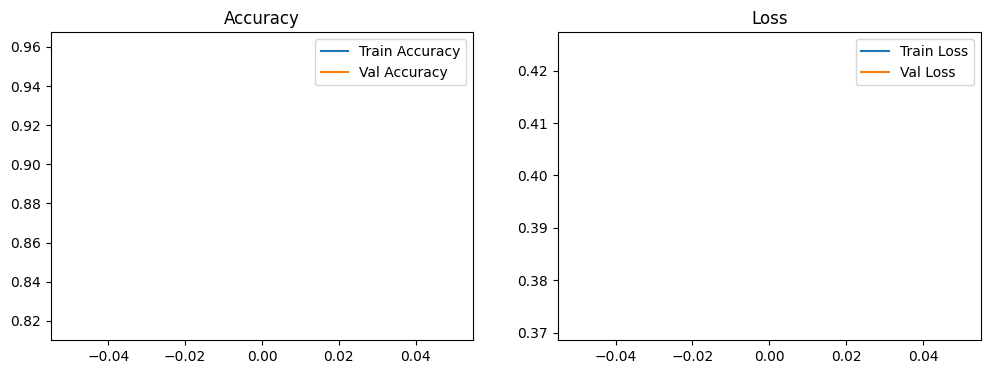

In [6]:
# 📈 Step 6: Visualize Training Results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [7]:
# 🧪 Step 7: Evaluate on Test Set
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.8172 - loss: 0.4247
Test Accuracy: 0.8172, Test Loss: 0.4247


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


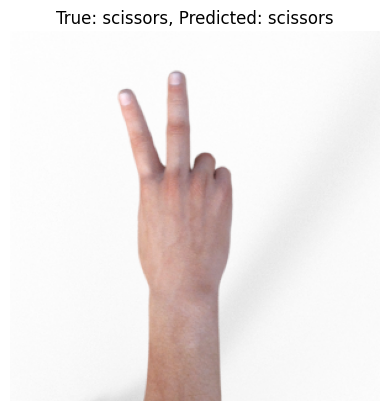

In [ ]:
# 🔍 Step 8: Inference on a Random Test Image


# Load test data again without batching
raw_test_ds = tfds.load('rock_paper_scissors', split='test', as_supervised=True)

# Pick a random test sample
sample_list = list(raw_test_ds)
sample_image, sample_label = random.choice(sample_list)

# Preprocess image
input_image = tf.image.resize(sample_image, (300, 300)) / 255.0
input_image = tf.expand_dims(input_image, axis=0)  # Add batch dimension
# Changes the shape from (300, 300, 3) to (1, 300, 300, 3).
# TensorFlow models never predict on a single image; they only predict on "batches." Even for one image, you must wrap it in a batch of size 1.
# Predict
pred = model.predict(input_image)
predicted_class = tf.argmax(pred[0]).numpy()

# Class labels
class_names = ds_info.features['label'].names

# Display
plt.imshow(sample_image)
plt.title(f"True: {class_names[sample_label]}, Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()

In [ ]:
'''AlexNet_Keras.ipynb
if you have tf.keras.layers.Resizing(300, 300) inside your Sequential model, you technically don't need to call tf.image.resize manually in your prediction script.'''

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


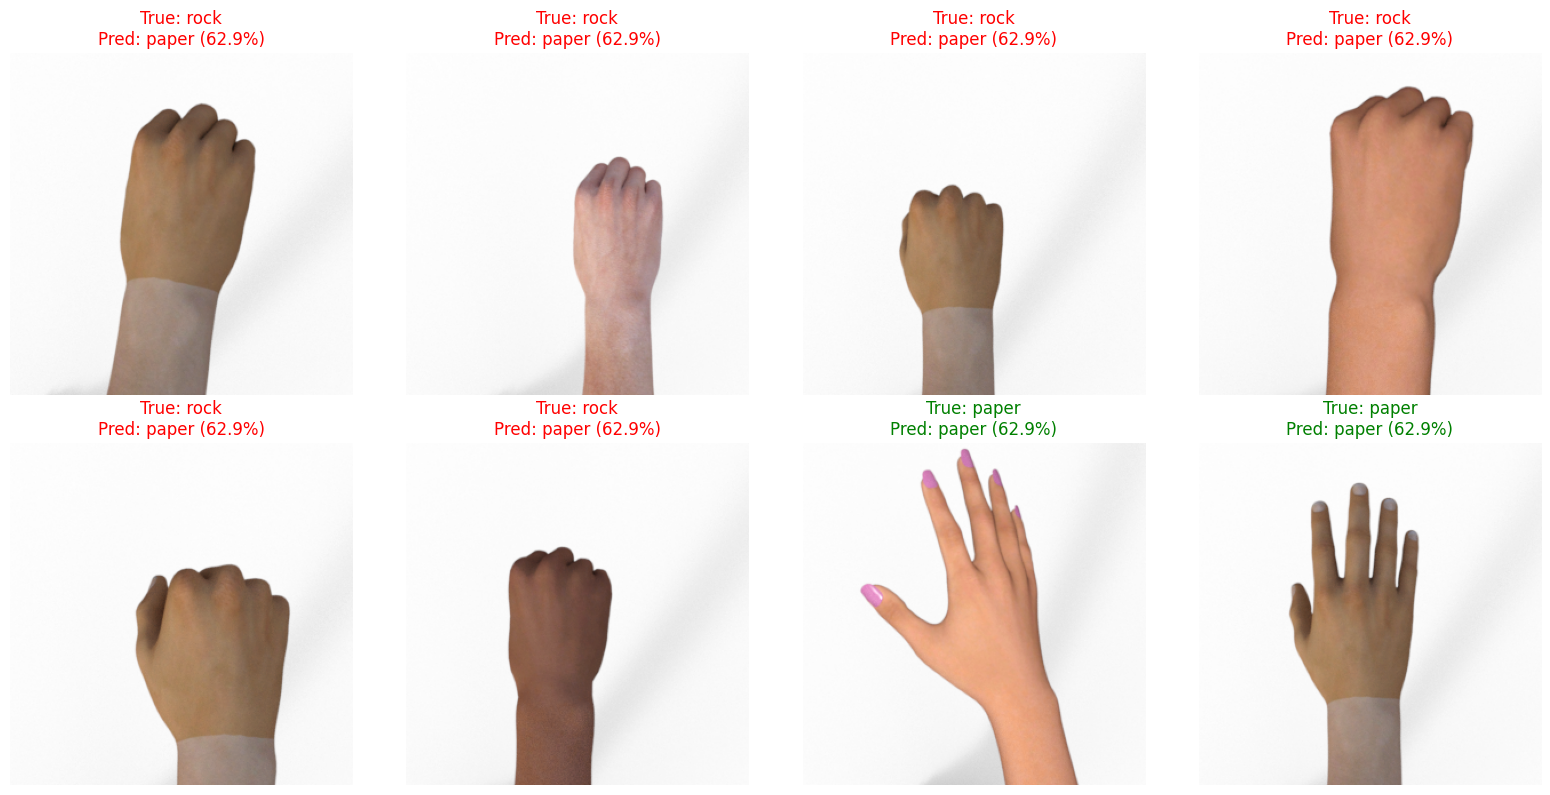

In [19]:
import random

# 1. Prepare the data (Converting to list to use random.sample)
raw_test_ds = tfds.load('rock_paper_scissors', split='test', as_supervised=True)
samples = list(raw_test_ds)
class_names = ds_info.features['label'].names

# 2. Create the subplot figure
plt.figure(figsize=(16, 8))

# 3. Loop to pick and predict 8 images
for i in range(8):
    # Pick random sample
    img, label = random.choice(samples)
    
    # Preprocess
    #input_img = tf.image.resize(img, (300, 300)) / 255.0
    #input_img = tf.expand_dims(input_img, axis=0)
    
    # Predict
    pred = model.predict(input_img)
    pred_idx = np.argmax(pred[0])
    confidence = 100 * np.max(pred[0])
    
    # Check if prediction is correct for coloring the title
    color = 'green' if pred_idx == label else 'red'
    
    # Plotting
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred_idx]} ({confidence:.1f}%)", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step


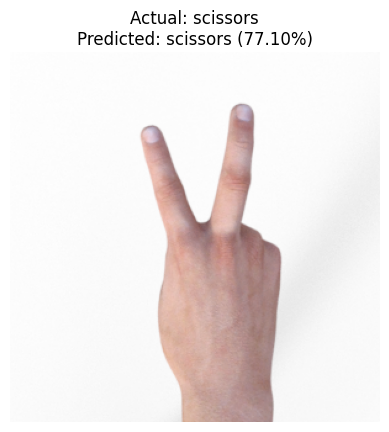

The model predicted scissors with 77.10% confidence.


In [ ]:
# 1. Grab one batch from your test dataset
# take(1) gets the first batch of 64 images
for images, labels in ds_test.take(1):
    sample_image = images[0]      # Get the first image from the batch
    sample_label = labels[0]      # Get its true label
    break

# 2. Add batch dimension (1, 300, 300, 3)
input_image = tf.expand_dims(sample_image, 0)

# 3. Predict
predictions = model.predict(input_image)
class_names = ds_info.features['label'].names
predicted_class = class_names[np.argmax(predictions)]
actual_class = class_names[sample_label]
confidence = 100 * np.max(predictions)

# 4. Display
plt.imshow(sample_image)
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"The model predicted {predicted_class} with {confidence:.2f}% confidence.")